In [62]:
import pandas as pd
import numpy as np

In [63]:
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [64]:
df = pd.read_csv("Titanic-Dataset.csv",usecols=['Age','Fare','Survived'])

In [65]:
df.dropna(inplace=True)

In [66]:
df.shape

(714, 3)

In [67]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [68]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [69]:
x_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [70]:
x_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [71]:
clf = DecisionTreeClassifier()

In [72]:
clf.fit(x_train,y_train)
y_pred = clf.predict(X_test)

In [73]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [74]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6261150234741784)

In [75]:
kbin_age = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')
kbin_fare = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')

In [76]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [77]:
x_train_trf = trf.fit_transform(x_train)
X_test_trf = trf.fit_transform(X_test)

In [78]:
trf.named_transformers_['first'].n_bins_

array([5])

In [79]:
trf.named_transformers_['first'].bin_edges_

array([array([ 1.        , 13.54505632, 25.49492263, 36.14664502, 48.33333333,
              62.        ])                                                   ],
      dtype=object)

In [80]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})

In [81]:
output['age_label'] = pd.cut(x = x_train['Age'],
    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_label'] = pd.cut(x = x_train['Fare'],
    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [82]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_label,fare_label
178,30.0,2.0,13.0000,0.0,"(25.495, 36.147]","(0.0, 35.744]"
429,32.0,2.0,8.0500,0.0,"(25.495, 36.147]","(0.0, 35.744]"
851,74.0,4.0,7.7750,0.0,NaN,"(0.0, 35.744]"
627,21.0,1.0,77.9583,1.0,"(13.545, 25.495]","(35.744, 90.827]"
503,37.0,2.0,9.5875,0.0,"(36.147, 48.333]","(0.0, 35.744]"


In [83]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [84]:
accuracy_score(y_test,y_pred2)

0.6293706293706294

In [85]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6289319248826291)

In [99]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")
    
    plt.show()

0.6275234741784038


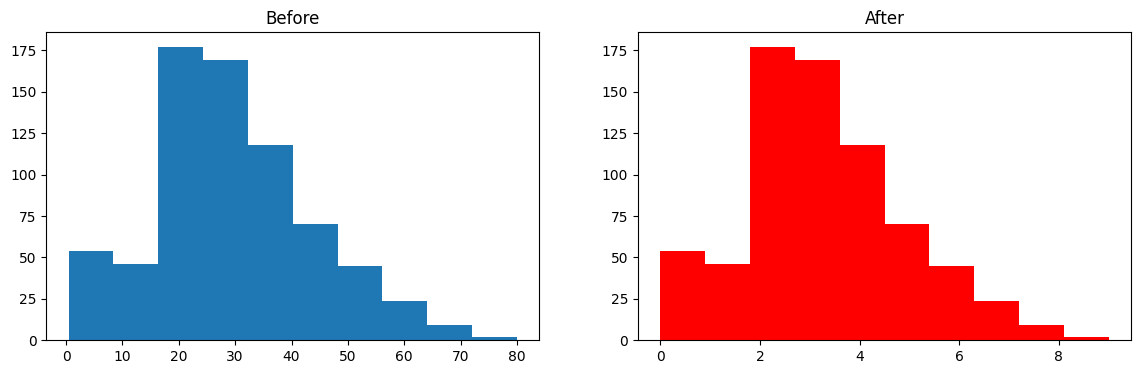

In [100]:
discretize(10,'uniform')

c:\Users\admin\anaconda3\envs\Machine-Learning\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\admin\anaconda3\envs\Machine-Learning\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.630320813771518


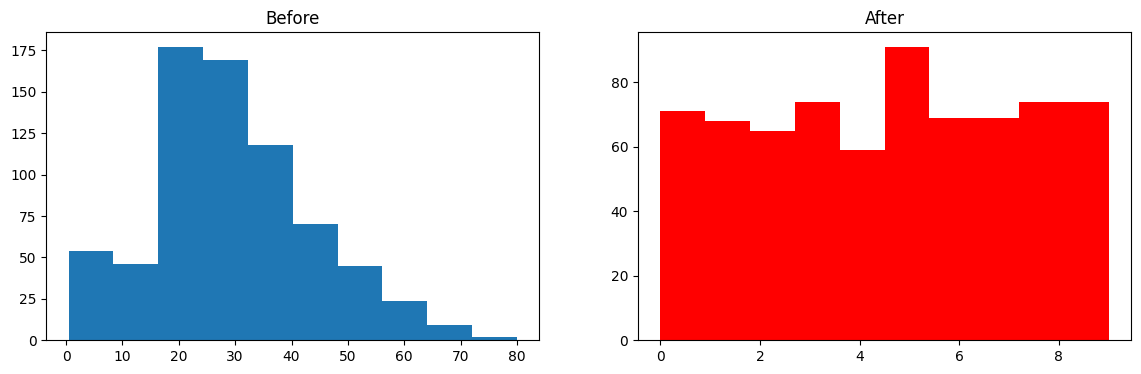

In [101]:
discretize(10,'quantile')

0.6331377151799686


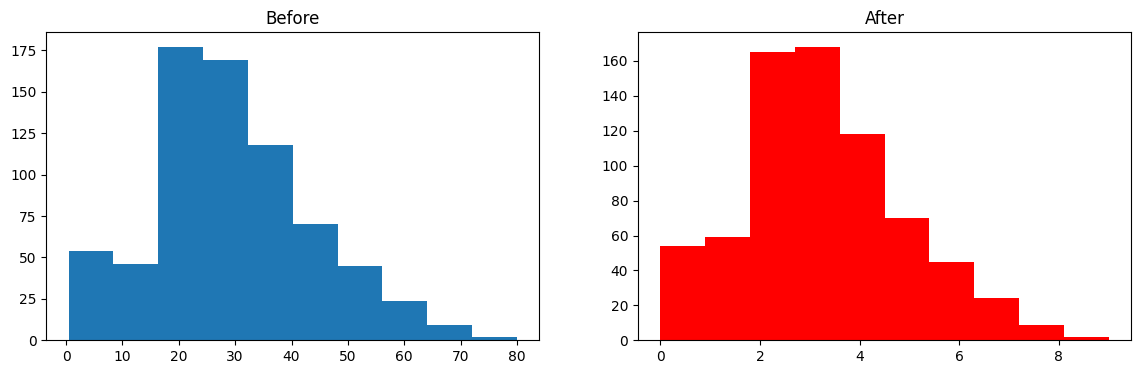

In [102]:
discretize(10,'kmeans')